### Imports

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.cluster import KMeans


### Data Preprocessing

In [2]:
IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    "flowers",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    "flowers",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)


Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.


### Build CNN Model

In [3]:
from tensorflow.keras.layers import BatchNormalization

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(256, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(train_data.num_classes, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


C:\Users\KIIT0001\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Train Model

In [4]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25
)


Epoch 1/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 702s 6s/step - accuracy: 0.4232 - loss: 3.1581 - val_accuracy: 0.2314 - val_loss: 8.2711
Epoch 2/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 457s 4s/step - accuracy: 0.5328 - loss: 1.1528 - val_accuracy: 0.2442 - val_loss: 5.4580
Epoch 3/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 437s 4s/step - accuracy: 0.5887 - loss: 1.0538 - val_accuracy: 0.3151 - val_loss: 2.1661
Epoch 4/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 718s 7s/step - accuracy: 0.6046 - loss: 1.0094 - val_accuracy: 0.4105 - val_loss: 4.0490
Epoch 5/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 372s 3s/step - accuracy: 0.6292 - loss: 0.9376 - val_accuracy: 0.5151 - val_loss: 1.3462
Epoch 6/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 278s 3s/step - accuracy: 0.6474 - loss: 0.9093 - val_accuracy: 0.5640 - val_loss: 1.3600
Epoch 7/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 277s 3s/step - accuracy: 0.7009 - loss: 0.7931 - val_accuracy: 0.6535 - val_loss: 0.9235
Epoch 8/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 277s 3s/step - accuracy: 0.6931 - loss: 0.8048 - val_accu

### Evaluate Model

In [5]:
loss, accuracy = model.evaluate(val_data)
print("Validation Accuracy:", accuracy)


27/27 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.7302 - loss: 0.8380
Validation Accuracy: 0.7302325367927551


### Plot Accuracy & Loss Graph

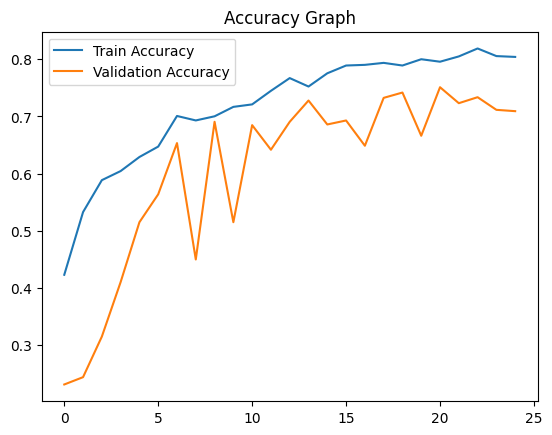

In [6]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()


### Detect Flower Color

In [7]:
import cv2
import numpy as np
from sklearn.cluster import KMeans

def get_color_name(rgb_color):

    hsv = cv2.cvtColor(
        np.uint8([[rgb_color]]),
        cv2.COLOR_RGB2HSV
    )[0][0]

    h, s, v = hsv

    if v < 30:
        return "Black"
    if s < 50 and v > 200:
        return "White"
    if s < 50 and v < 100:
        return "Gray"

    if h < 10 or h > 170:
        if s > 150:
            return "Red"
        else:
            return "Pink"
    elif 10 <= h < 18:
        return "Orange"
    elif 18 <= h < 35:
        return "Yellow"
    elif 35 <= h < 85:
        return "Green"
    elif 85 <= h < 125:
        return "Blue"
    elif 125 <= h < 160:
        return "Purple"
    else:
        return "Pink"


def detect_flower_color(image_path):

    # Read and resize
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224,224))

    # Convert to HSV and remove green background
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    lower_green = np.array([35, 40, 40])
    upper_green = np.array([85, 255, 255])
    green_mask = cv2.inRange(hsv, lower_green, upper_green)
    flower_mask = cv2.bitwise_not(green_mask)
    flower_only = cv2.bitwise_and(image, image, mask=flower_mask)

    # Flatten and remove background black
    pixels = flower_only.reshape((-1,3))
    pixels = pixels[np.any(pixels != [0,0,0], axis=1)]

    if len(pixels) < 50:
        pixels = image.reshape((-1,3))

    # Apply KMeans
    kmeans = KMeans(n_clusters=3, n_init=10)
    kmeans.fit(pixels)

    colors = kmeans.cluster_centers_
    labels = kmeans.labels_
    counts = np.bincount(labels)

    # Pick dominant color by SIZE (not saturation)
    dominant_color = colors[np.argmax(counts)].astype(int)

    color_name = get_color_name(dominant_color)

    print("\n===== COLOR DETECTION =====")
    print("Dominant RGB:", dominant_color)
    print("Detected Flower Color:", color_name)


### Prediction Function

In [2]:
def predict_flower(image_path):

    img = tf.keras.preprocessing.image.load_img(
        image_path, target_size=(224,224)
    )

    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    class_index = np.argmax(prediction)
    confidence = np.max(prediction)

    classes = list(train_data.class_indices.keys())

    print("Predicted Flower:", classes[class_index])
    print("Confidence:", confidence)

    detect_flower_color(image_path)


### Input

In [3]:
predict_flower('orange_tulip.png')

NameError: name 'tf' is not defined